# IBM HR Analytics — Análisis de Rotación de Empleados
**Dataset:** IBM HR Employee Attrition Dataset — 1,470 empleados × 35 variables  
**Objetivo:** Identificar los factores que impulsan la rotación de empleados y construir un modelo predictivo para apoyar decisiones de retención.

---
## Tabla de contenidos
1. [Carga y limpieza de datos](#1)
2. [Análisis Exploratorio (EDA)](#2)
3. [Análisis de correlaciones](#3)
4. [Modelo predictivo de rotación](#4)
5. [Conclusiones y recomendaciones](#5)


## 1. Carga y Limpieza de Datos <a id='1'></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('muted')

import os
os.makedirs('outputs', exist_ok=True)


In [21]:
df = pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
print(f"Shape: {df.shape}")
df.head(3)


Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0


In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [23]:
print("=== Resumen de nulos ===")
print(df.isnull().sum())

=== Resumen de nulos ===
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentR

In [24]:
print(df['JobSatisfaction'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

JobSatisfaction
4    31.22%
3    30.07%
1    19.66%
2    19.05%
Name: proportion, dtype: str


In [25]:
# Resumen de variables categóricas --- IGNORE ---
cat_cols= df.select_dtypes(include='object').columns
print("=== Resumen de variables categóricas ===")
for col in cat_cols:
    print(f"{col:30s} → {df[col].nunique():4d} categorías únicas")
print("\n=== Distribución de categorías (en %) ===")
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

for col in cat_cols:
    print(f"{col:30s} → {df[col].nunique():4d} categorías únicas")

=== Resumen de variables categóricas ===
Attrition                      →    2 categorías únicas
BusinessTravel                 →    3 categorías únicas
Department                     →    3 categorías únicas
EducationField                 →    6 categorías únicas
Gender                         →    2 categorías únicas
JobRole                        →    9 categorías únicas
MaritalStatus                  →    3 categorías únicas
Over18                         →    1 categorías únicas
OverTime                       →    2 categorías únicas

=== Distribución de categorías (en %) ===

Attrition:
Attrition
No     83.88%
Yes    16.12%
Name: proportion, dtype: str

BusinessTravel:
BusinessTravel
Travel_Rarely        70.95%
Travel_Frequently    18.84%
Non-Travel            10.2%
Name: proportion, dtype: str

Department:
Department
Research & Development    65.37%
Sales                     30.34%
Human Resources            4.29%
Name: proportion, dtype: str

EducationField:
EducationField
Life

### 1.1 Limpieza

In [ ]:
# Eliminar columnas constantes sin valor analítico
df.drop(columns=['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber'], inplace=True)

# Variable target binaria
df['Attrition_bin'] = (df['Attrition'] == 'Yes').astype(int)

# Mapear escalas ordinales a etiquetas legibles
satisfaction_map = {1: 'Bajo', 2: 'Medio', 3: 'Alto', 4: 'Muy Alto'}
df['JobSatisfaction_label']         = df['JobSatisfaction'].map(satisfaction_map)
df['EnvironmentSatisfaction_label'] = df['EnvironmentSatisfaction'].map(satisfaction_map)
df['WorkLifeBalance_label']         = df['WorkLifeBalance'].map({1:'Malo', 2:'Regular', 3:'Bueno', 4:'Excelente'})

print(f"   Limpieza completa")
print(f"   Empleados totales:  {len(df):,}")
print(f"   Rotación (Yes):     {df['Attrition_bin'].sum():,} ({df['Attrition_bin'].mean()*100:.1f}%)")
print(f"   Sin rotación (No):  {(df['Attrition_bin']==0).sum():,} ({(1-df['Attrition_bin'].mean())*100:.1f}%)")


   Limpieza completa
   Empleados totales:  1,470
   Rotación (Yes):     237 (16.1%)
   Sin rotación (No):  1,233 (83.9%)


## 2. Análisis Exploratorio de Datos <a id='2'></a>

### 2.1 Perfil demográfico — Edad, género y estado civil

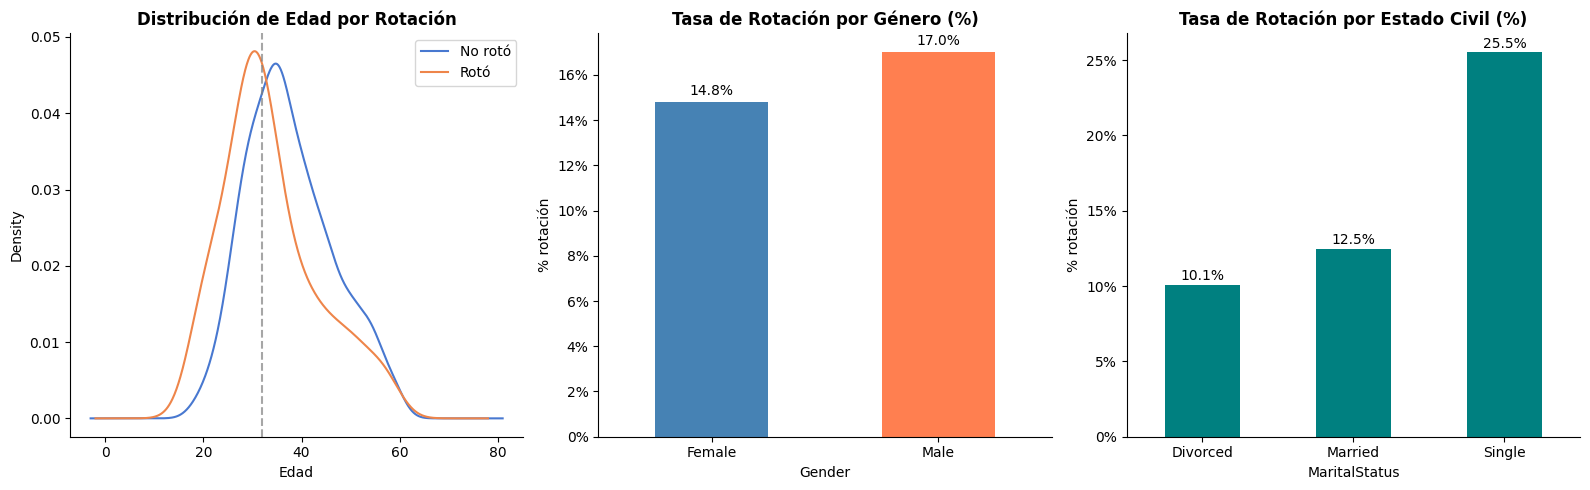

Datos sobre la distribución de Edad por rotación:


count    237.000000
mean      33.607595
std        9.689350
min       18.000000
25%       28.000000
50%       32.000000
75%       39.000000
max       58.000000
Name: Age, dtype: float64

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Distribución de edad por attrition
df.groupby('Attrition')['Age'].plot(kind='kde', ax=axes[0], legend=True)
axes[0].set_title('Distribución de Edad por Rotación', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Edad')
axes[0].axvline(df[df['Attrition_bin']==1]['Age'].median(), color='gray', linestyle='--', alpha=0.7, label=f'Media: {df[df["Attrition_bin"]==1]["Age"].median():.1f} años')
axes[0].legend(['No rotó', 'Rotó'])

# Tasa de rotación por género
gender_attr = df.groupby('Gender')['Attrition_bin'].mean() * 100
gender_attr.plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], rot=0)
axes[1].set_title('Tasa de Rotación por Género (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% rotación')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

# Tasa de rotación por estado civil
marital_attr = df.groupby('MaritalStatus')['Attrition_bin'].mean() * 100
marital_attr.sort_values(ascending=True).plot(kind='bar', ax=axes[2], color='teal', rot=0)
axes[2].set_title('Tasa de Rotación por Estado Civil (%)', fontsize=12, fontweight='bold')
axes[2].set_ylabel('% rotación')
axes[2].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('outputs/hr_01_demographic.png', dpi=150, bbox_inches='tight')
plt.show()
#Empleados solteros tienen casi el doble de tasa de rotación que casados y divorciados.

print("Datos sobre la distribución de Edad por rotación:")
df[df['Attrition_bin']==1]['Age'].describe()
#print(f"Edad de mayor rotación: {df[df['Attrition_bin']==1]['Age'].median():.1f} años")

### 2.2 Departamento y rol — ¿Dónde se concentra la rotación?

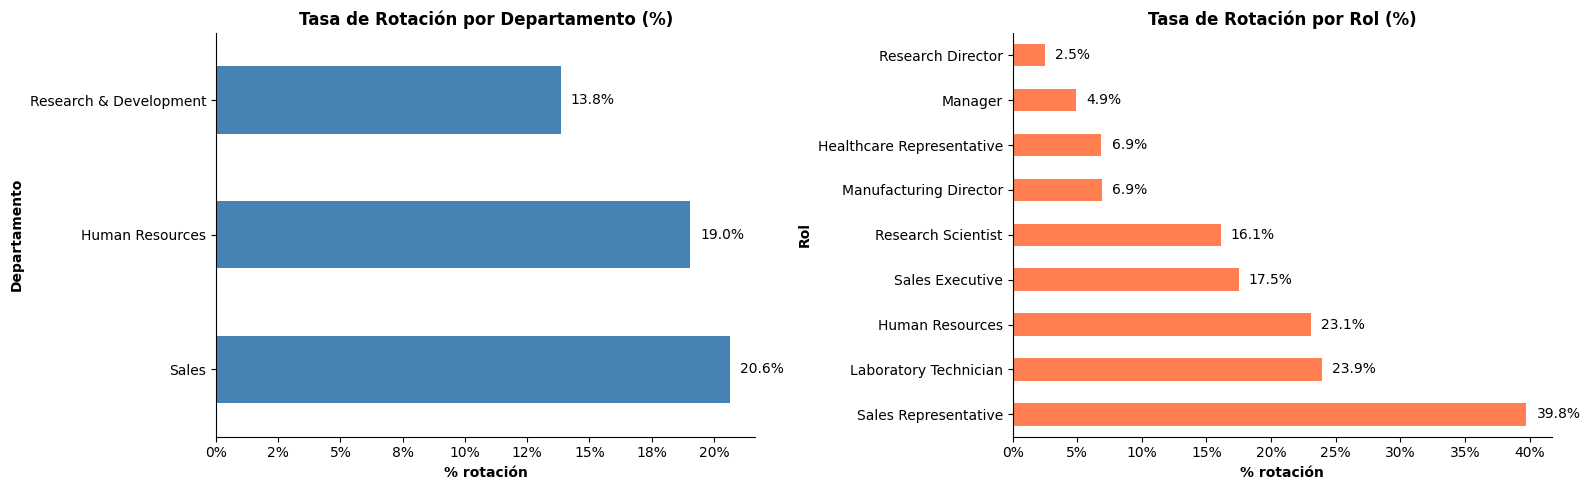

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Por departamento
dept_attr = df.groupby('Department')['Attrition_bin'].mean() * 100
dept_attr.sort_values(ascending=False).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Tasa de Rotación por Departamento (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Departamento', fontweight='bold')
axes[0].set_xlabel('% rotación', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in axes[0].patches:
    width = bar.get_width()
    if width > 0: # Evita etiquetar barras vacías si existen
        axes[0].text(
            width + (dept_attr.max() * 0.02), # Espacio dinámico a la derecha de la barra
            bar.get_y() + bar.get_height() / 2,
            f'{width:.1f}%', # El ancho de la barra ya es el porcentaje correcto
            va='center', 
            ha='left', 
            fontsize=10
        )
# Por rol
role_attr = df.groupby('JobRole')['Attrition_bin'].mean() * 100
role_attr.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Tasa de Rotación por Rol (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Rol', fontweight='bold')
axes[1].set_xlabel('% rotación', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

for bar in axes[1].patches:
    width = bar.get_width()
    if width > 0: # Evita etiquetar barras vacías si existen
        axes[1].text(
            width + (role_attr.max() * 0.02), # Espacio dinámico a la derecha de la barra
            bar.get_y() + bar.get_height() / 2,
            f'{width:.1f}%', # El ancho de la barra ya es el porcentaje correcto
            va='center', 
            ha='left', 
            fontsize=10
        )
plt.tight_layout()
plt.savefig('outputs/hr_02_department_role.png', dpi=150, bbox_inches='tight')
plt.show()
# Los departamentos con mayor rotación corresponden al departamento de ventas y recursos humanos. Sales Representative y Laboratory Technician tienen las tasas más altas de rotación.


### 2.3 Salario y años en la empresa

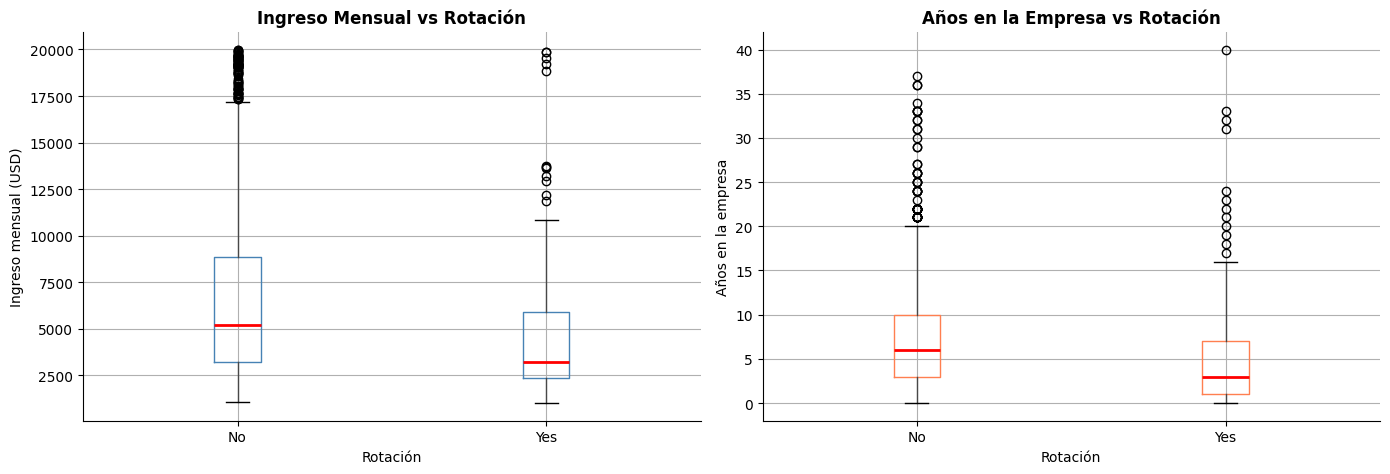

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ingreso mensual por attrition
df.boxplot(column='MonthlyIncome', by='Attrition', ax=axes[0],
           boxprops=dict(color='steelblue'),
           medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Ingreso Mensual vs Rotación', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Rotación')
axes[0].set_ylabel('Ingreso mensual (USD)')
plt.sca(axes[0])
plt.title('Ingreso Mensual vs Rotación', fontsize=12, fontweight='bold')

# Años en la empresa por attrition
df.boxplot(column='YearsAtCompany', by='Attrition', ax=axes[1],
           boxprops=dict(color='coral'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Años en la Empresa vs Rotación', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Rotación')
axes[1].set_ylabel('Años en la empresa')
plt.sca(axes[1])
plt.title('Años en la Empresa vs Rotación', fontsize=12, fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.savefig('outputs/hr_03_income_years.png', dpi=150, bbox_inches='tight')
plt.show()
# Empleados que rotan tienen menor ingreso y menos años en la empresa en promedio.


### 2.4 Overtime — ¿El trabajo extra impulsa la salida?

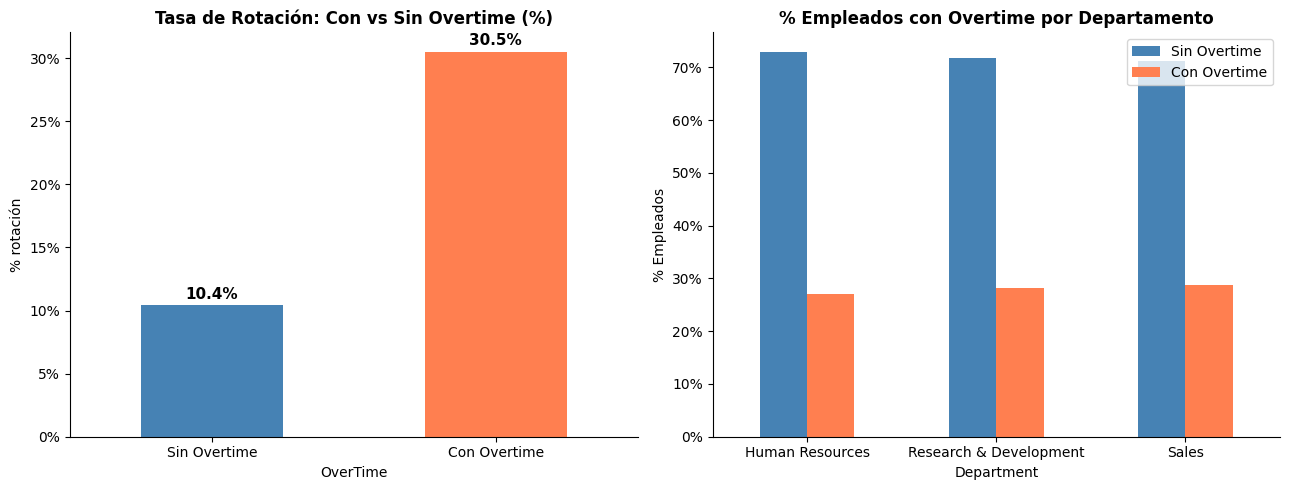

In [57]:
overtime_attr = df.groupby('OverTime')['Attrition_bin'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Tasa de rotación por overtime
overtime_attr.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], rot=0)
axes[0].set_title('Tasa de Rotación: Con vs Sin Overtime (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% rotación')
axes[0].set_xticklabels(['Sin Overtime', 'Con Overtime'])
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

# Distribución overtime por departamento
overtime_dept = df.groupby(['Department', 'OverTime']).size().unstack(fill_value=0)
overtime_dept.div(overtime_dept.sum(axis=1), axis=0).mul(100).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], rot=0)
axes[1].set_title('% Empleados con Overtime por Departamento', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% Empleados')
axes[1].legend(['Sin Overtime', 'Con Overtime'])
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.tight_layout()
plt.savefig('outputs/hr_04_overtime.png', dpi=150, bbox_inches='tight')
plt.show()
#Empleados con overtime tienen 3x más probabilidad de rotación.


### 2.5 Satisfacción laboral y balance vida-trabajo

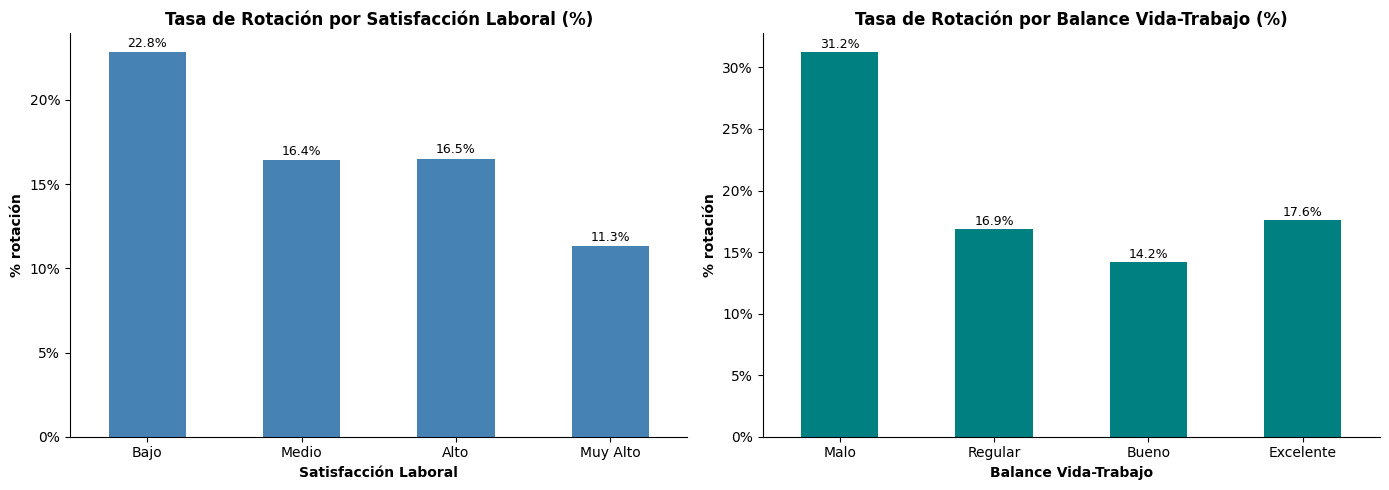

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_sat  = ['Bajo', 'Medio', 'Alto', 'Muy Alto']
order_wlb  = ['Malo', 'Regular', 'Bueno', 'Excelente']

# Job Satisfaction
sat_attr = df.groupby('JobSatisfaction_label')['Attrition_bin'].mean() * 100
sat_attr = sat_attr.reindex(order_sat)
sat_attr.plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Tasa de Rotación por Satisfacción Laboral (%)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('% rotación', fontweight='bold')
axes[0].set_xlabel('Satisfacción Laboral', fontweight='bold')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

# Work Life Balance
wlb_attr = df.groupby('WorkLifeBalance_label')['Attrition_bin'].mean() * 100
wlb_attr = wlb_attr.reindex(order_wlb)
wlb_attr.plot(kind='bar', ax=axes[1], color='teal', rot=0)
axes[1].set_title('Tasa de Rotación por Balance Vida-Trabajo (%)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('% rotación', fontweight='bold')
axes[1].set_xlabel('Balance Vida-Trabajo', fontweight='bold')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/hr_05_satisfaction.png', dpi=150, bbox_inches='tight')
plt.show()
#Satisfacción baja duplica la tasa de rotación vs satisfacción muy alta. Satisfacción Malo de Balance Vida-Trabajo tiene la tasa más alta de rotación.


### 2.6 Viajes de negocio

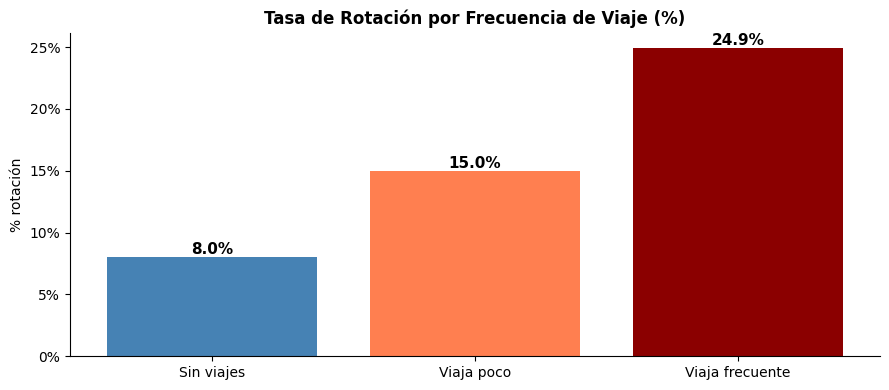

In [63]:
travel_attr = df.groupby('BusinessTravel')['Attrition_bin'].mean() * 100
travel_order = ['Non-Travel', 'Travel_Rarely', 'Travel_Frequently']
travel_attr = travel_attr.reindex(travel_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(travel_attr.index, travel_attr.values, color=['steelblue', 'coral', 'darkred'])
ax.set_title('Tasa de Rotación por Frecuencia de Viaje (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('% rotación')
ax.set_xticklabels(['Sin viajes', 'Viaja poco', 'Viaja frecuente'], rotation=0)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/hr_06_travel.png', dpi=150, bbox_inches='tight')
plt.show()
#Empleados que viajan frecuentemente tienen la tasa de rotación más alta (24.9%).


### 2.7 Análisis de Cohortes por Antigüedad

In [94]:
bins = [0, 2, 5, 10, 20, 40]
labels = ['0-2 años', '3-5 años', '6-10 años', '11-20 años', '20+ años']
df['cohorte'] = pd.cut(df['YearsAtCompany'], bins=bins, labels=labels)

cohort_attr = df.groupby('cohorte')['Attrition_bin'].agg(['mean', 'count']).reset_index()
cohort_attr['mean'] = cohort_attr['mean'] * 100
print(cohort_attr)

      cohorte       mean  count
0    0-2 años  28.859060    298
1    3-5 años  13.824885    434
2   6-10 años  12.276786    448
3  11-20 años   6.666667    180
4    20+ años  12.121212     66


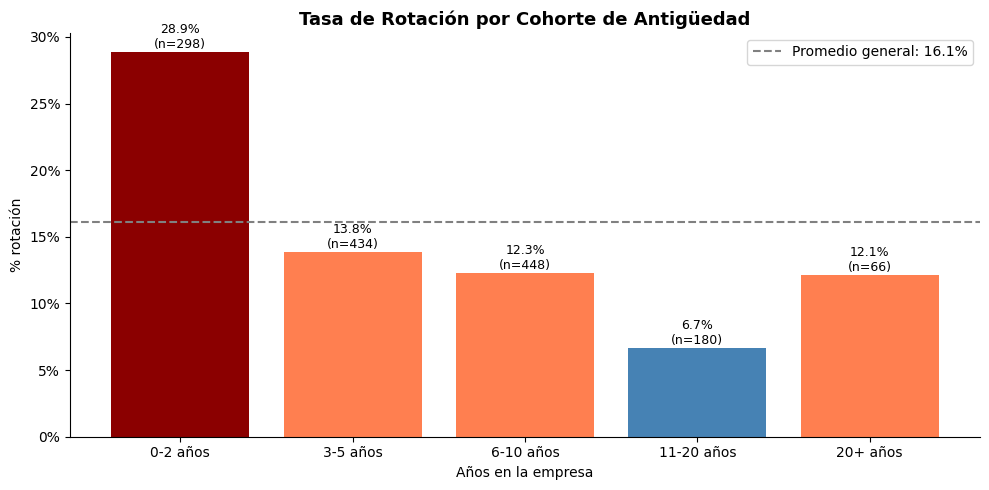

In [111]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['darkred' if v > 20 else 'coral' if v > 12 else 'steelblue' 
          for v in cohort_attr['mean']]

bars = ax.bar(cohort_attr['cohorte'], cohort_attr['mean'], color=colors)
ax.axhline(df['Attrition_bin'].mean() * 100, color='gray', linestyle='--', 
           label=f'Promedio general: {df["Attrition_bin"].mean()*100:.1f}%')
ax.set_title('Tasa de Rotación por Cohorte de Antigüedad', fontsize=13, fontweight='bold')
ax.set_xlabel('Años en la empresa')
ax.set_ylabel('% rotación')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()

for bar, row in zip(bars, cohort_attr.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{row.mean:.1f}%\n(n={row.count})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/hr_11_cohorts.png', dpi=150, bbox_inches='tight')
plt.show()

#Los primeros 2 años son críticos, la tasa de rotación de 28.9%, casi el doble del promedio.
#A partir del año 6 la rotación cae significativamente, sugiriendo que superar ese umbral genera arraigo.

## 3. Análisis de Correlaciones <a id='3'></a>

Identificamos qué variables numéricas tienen mayor relación con la rotación.

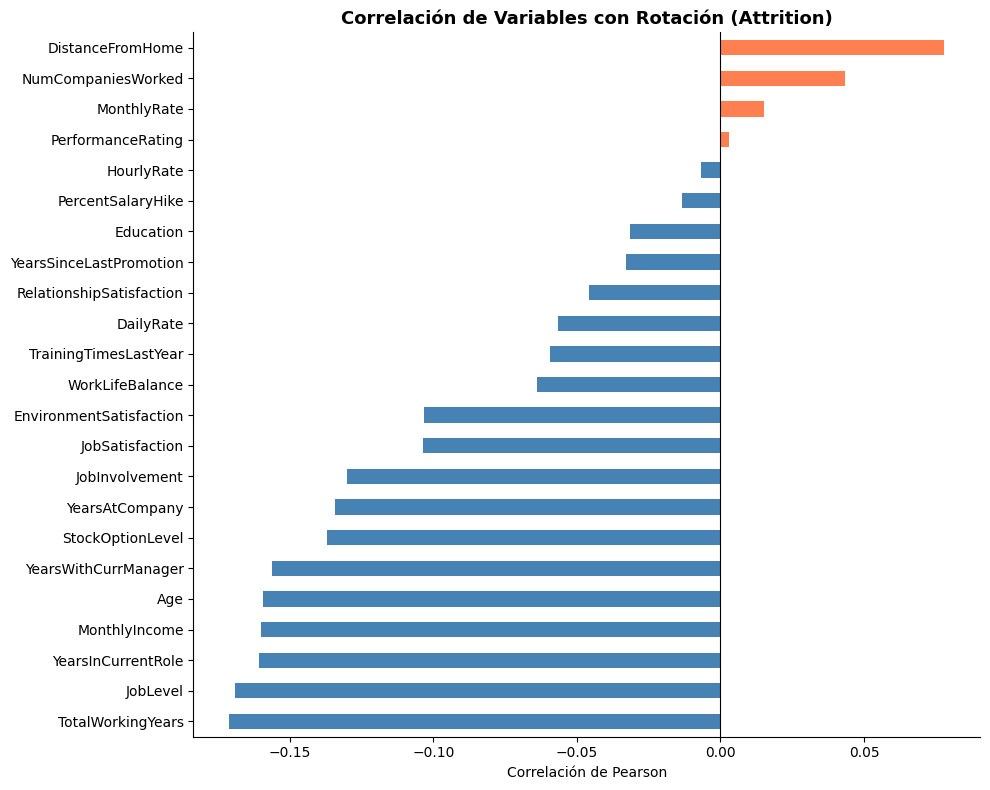

In [66]:
num_cols = df.select_dtypes(include='number').columns.tolist()
num_cols = [c for c in num_cols if c not in ['Attrition_bin']]

corr_with_attrition = df[num_cols + ['Attrition_bin']].corr()['Attrition_bin'].drop('Attrition_bin')
corr_with_attrition = corr_with_attrition.sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['coral' if v > 0 else 'steelblue' for v in corr_with_attrition.values]
corr_with_attrition.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Variables con Rotación (Attrition)', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')

plt.tight_layout()
plt.savefig('outputs/hr_07_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
#Variables en coral correlacionan positivamente con rotación (más = mayor es la probabilidad de rotación)
#Variables en azul correlacionan negativamente (más = menos riesgo de rotación)


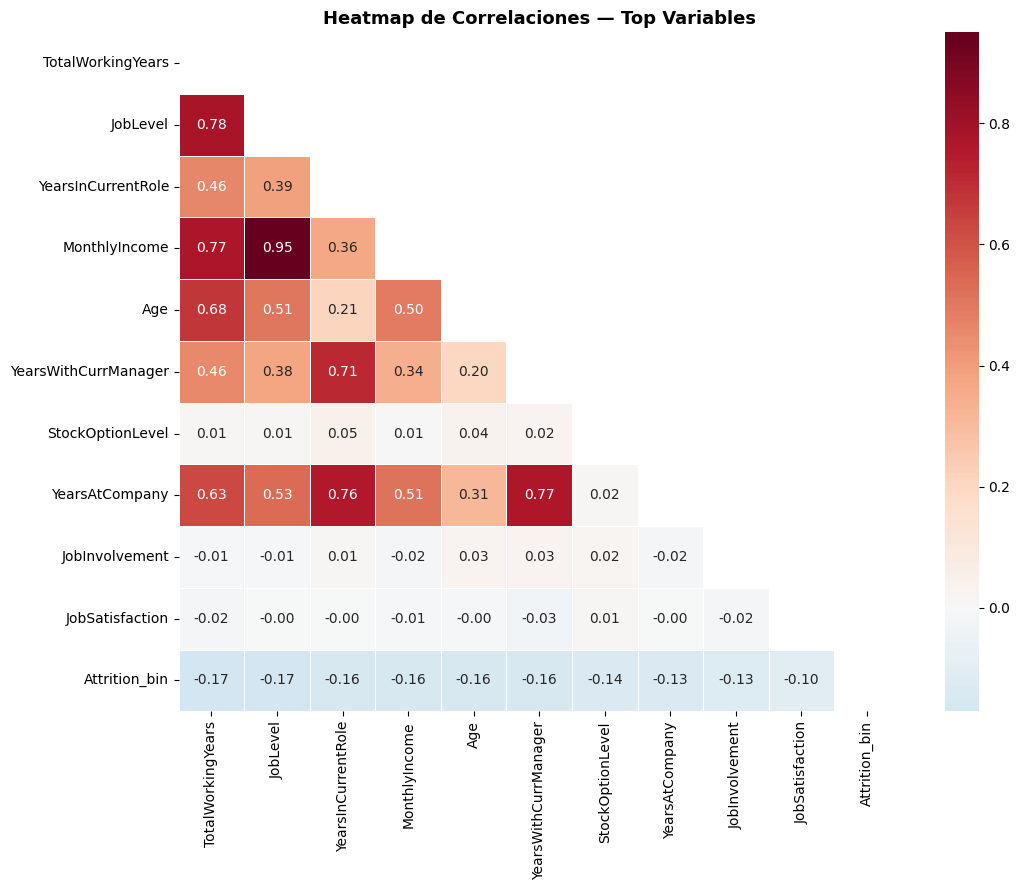

In [74]:
# Heatmap de variables más correlacionadas con attrition
top_vars = corr_with_attrition.abs().sort_values(ascending=False).head(10).index.tolist()
top_vars.append('Attrition_bin')

fig, ax = plt.subplots(figsize=(11, 9))
corr_matrix = df[top_vars].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, ax=ax, linewidths=0.5)
ax.set_title('Heatmap de Correlaciones — Top Variables', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/hr_08_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Modelo Predictivo de Rotación <a id='4'></a>

**Objetivo:** Predecir qué empleados tienen mayor riesgo de abandonar la empresa.  
**Valor de negocio:** Permite al área de RRHH intervenir proactivamente con planes de retención personalizados.


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Feature Engineering
ml_df = df.copy()

# Codificar variables categóricas
cat_cols = ['BusinessTravel', 'Department', 'EducationField',
            'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
le = LabelEncoder()
for col in cat_cols:
    ml_df[col] = le.fit_transform(ml_df[col].astype(str))

# Selección de features
feature_cols = ['Age', 'BusinessTravel', 'DailyRate', 'Department',
                'DistanceFromHome', 'Education', 'EnvironmentSatisfaction',
                'Gender', 'JobInvolvement', 'JobLevel', 'JobRole',
                'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome',
                'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike',
                'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
                'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
                'YearsSinceLastPromotion', 'YearsWithCurrManager']

X = ml_df[feature_cols]
y = ml_df['Attrition_bin']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"Balance — Rotación: {y.mean()*100:.1f}%")


Train: 1,176 | Test: 294
Balance — Rotación: 16.1%


In [ ]:
# ── Random Forest ──────────────────────────────────────────────────────────────
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid,
    scoring='f1',       # Mantiene métrica para datos desbalanceados
    cv=5,               # Validación cruzada de 5 pliegues
    n_jobs=-1
)
grid.fit(X_train, y_train)
print(f"Mejores parámetros: {grid.best_params_}")

In [84]:
# ── Gradient Booster ──────────────────────────────────────────────────────────────

param_grid = {
    'n_estimators': [100, 200],         
    'learning_rate': [0.01, 0.1],       
    'max_depth':[5, 10, None],             
    'min_samples_leaf': [1, 5, 10]      
}

grid = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    scoring='f1',                       # Mantiene métrica para datos desbalanceados
    cv=5,                               # Validación cruzada de 5 pliegues
    n_jobs=-1                           
)

# 3. Entrenar la búsqueda en cuadrícula
grid.fit(X_train, y_train)

# 4. Mostrar resultados
print(f"Mejores parámetros: {grid.best_params_}")


/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: invalid escape sequence '\s'
  match = re.match("^#\s*version\s*([0-9a-z]*)\s*$", line)
/usr/lib/python3/dist-packages/pytz/__init__.py:31: SyntaxWarning: inv

Mejores parámetros: {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 200}


In [92]:
# Entrenar tres modelos
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, min_samples_leaf=5, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    auc   = roc_auc_score(y_test, proba)
    results[name] = {'model': model, 'pred': pred, 'proba': proba, 'auc': auc}
    print(f"=== {name} ===")
    print(classification_report(y_test, pred, target_names=['No rotó', 'Rotó']))
    print(f"ROC-AUC: {auc:.4f}\n")


=== Logistic Regression ===
              precision    recall  f1-score   support

     No rotó       0.92      0.69      0.79       247
        Rotó       0.30      0.70      0.42        47

    accuracy                           0.69       294
   macro avg       0.61      0.70      0.60       294
weighted avg       0.82      0.69      0.73       294

ROC-AUC: 0.7906

=== Random Forest ===
              precision    recall  f1-score   support

     No rotó       0.89      0.91      0.90       247
        Rotó       0.47      0.40      0.44        47

    accuracy                           0.83       294
   macro avg       0.68      0.66      0.67       294
weighted avg       0.82      0.83      0.83       294

ROC-AUC: 0.7915

=== Gradient Boosting ===
              precision    recall  f1-score   support

     No rotó       0.86      0.97      0.91       247
        Rotó       0.56      0.19      0.29        47

    accuracy                           0.85       294
   macro avg      

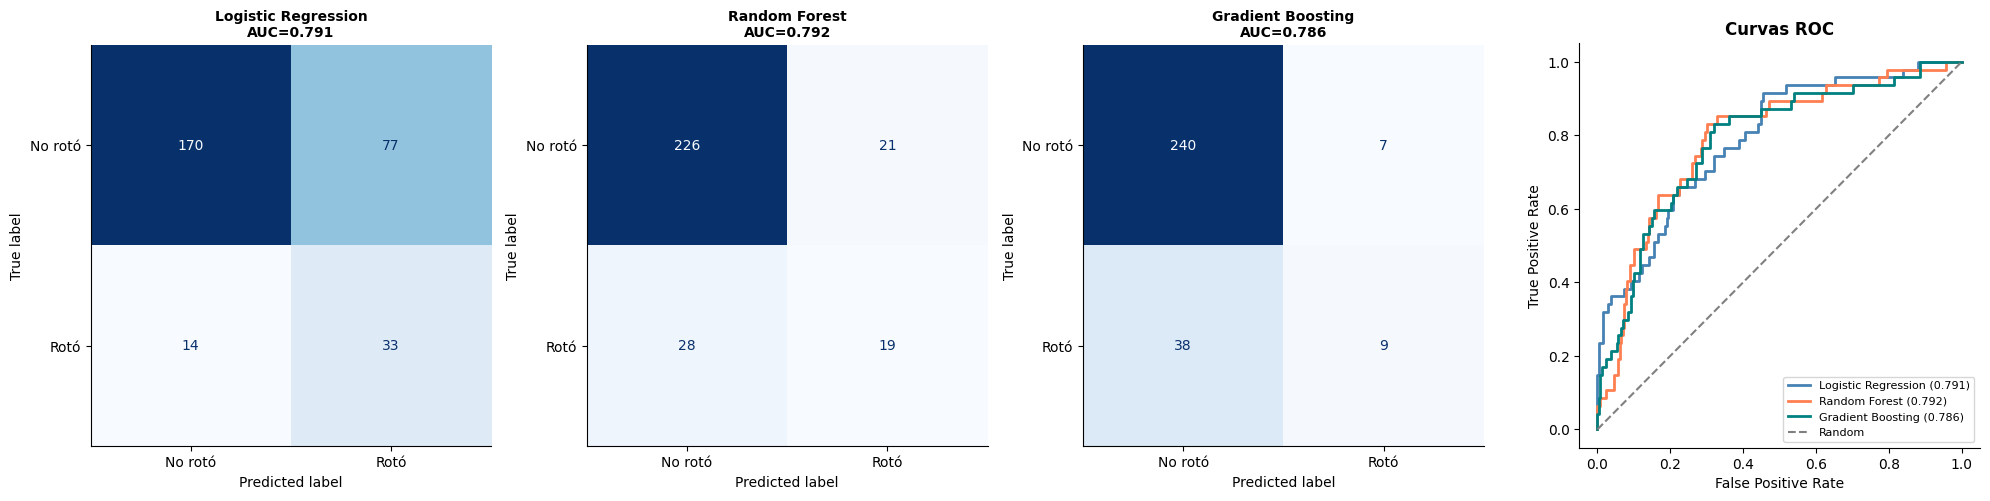

In [93]:
# Comparativa visual
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No rotó', 'Rotó'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAUC={res["auc"]:.3f}', fontsize=10, fontweight='bold')

# ROC Curves
colors_roc = ['steelblue', 'coral', 'teal']
for (name, res), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, res['proba'])
    axes[3].plot(fpr, tpr, label=f'{name} ({res["auc"]:.3f})', color=color, lw=2)

axes[3].plot([0,1],[0,1],'--', color='gray', label='Random')
axes[3].set_title('Curvas ROC', fontsize=12, fontweight='bold')
axes[3].set_xlabel('False Positive Rate')
axes[3].set_ylabel('True Positive Rate')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.savefig('outputs/hr_09_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


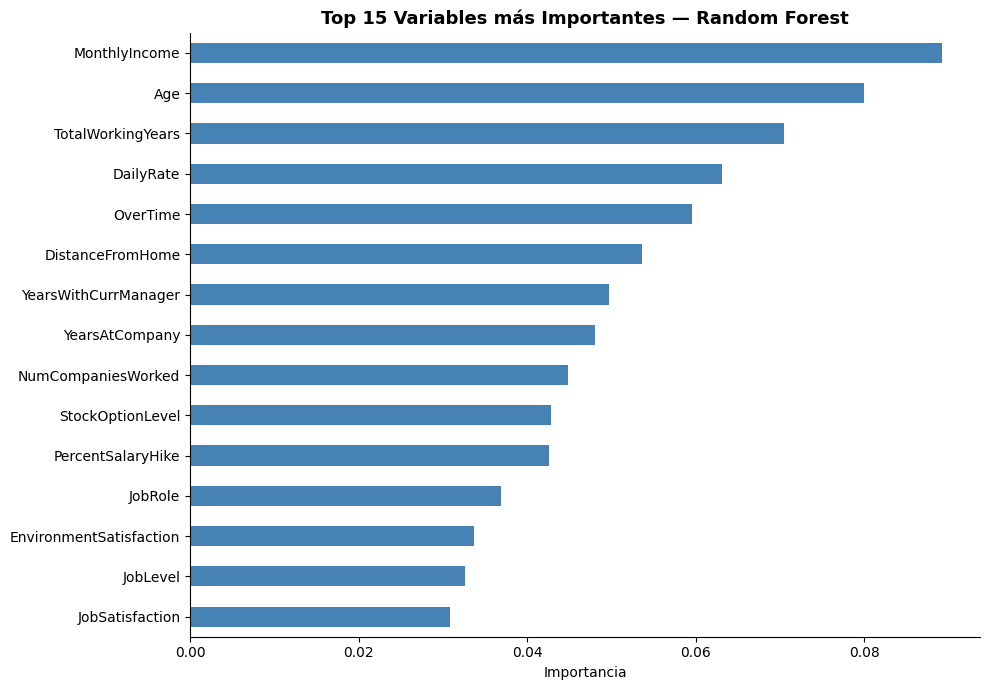

In [89]:
# Feature Importance — Random Forest
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 15 Variables más Importantes — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia')

plt.tight_layout()
plt.savefig('outputs/hr_10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
#Las variables más importantes revelan qué factores debe atender RRHH prioritariamente.


## 5. Conclusiones y Recomendaciones <a id='5'></a>

### Hallazgos principales

| # | Hallazgo | Recomendación |
|---|----------|---------------|
| 1 | Empleados **solteros** tienen ~2x más rotación que casados | Programas de integración social y comunidad |
| 2 | **Overtime** triplica la probabilidad de rotación | Auditar carga de trabajo; compensar horas extra |
| 3 | **Sales Representative** y **Laboratory Technician** lideran rotación | Revisar estructura salarial y plan de carrera en estos roles |
| 4 | Empleados con **bajo ingreso** y **pocos años** tienen mayor riesgo | Programas de retención temprana (primeros 2 años) |
| 5 | **Viajes frecuentes** elevan la rotación a ~25% | Política de compensación por viaje y flexibilidad remota |
| 6 | **Satisfacción baja** duplica la tasa de rotación | Encuestas de pulso trimestrales con plan de acción |
| 7 | **Los primeros 2 años son críticos**, la tasa de rotación es del 28.9% | Programas de retención temprana (primeros 2 años) |
### Rendimiento de modelos

| Modelo | ROC-AUC | Recall Rotación | Observación |
|--------|---------|-----------------|-------------|
| Logistic Regression | 0.791 | 70% | Detecta más rotaciones reales — recomendado para RRHH |
| Random Forest | 0.792 | 40% | Mejor precisión, menos falsas alarmas |
| Gradient Boosting | 0.786 | 19% | Muy conservador — no apto para detección de rotación |
